# LS y PCA con datos de Spotify

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
---

Usamos el dataset público de Spotify (~32k canciones) con features de audio medidas algorítmicamente.

**Hilo del notebook:**

| Bloque | Problema | Herramienta |
|--------|----------|-------------|
| 1 | Predecir `energy` desde `loudness` (1 variable) | LS en 2D |
| 2 | Predecir `popularity` desde todas las features | LS en $\mathbb{R}^d$ |
| 3 | Encontrar estructura en las 10 features de audio | PCA |

En los tres bloques el problema algebraico es el mismo: $\min_\mathbf{c}\|A\mathbf{c}-\mathbf{y}\|^2$.
La diferencia está en qué es $A$, qué es $\mathbf{y}$, y si $\mathbf{y}$ existe.

In [10]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


In [11]:

import pandas as pd

# ── Descargar dataset de Spotify desde GitHub (Kaggle mirror público) ────────
URL = ('https://raw.githubusercontent.com/rfordatascience/tidytuesday/'
       'master/data/2020/2020-01-21/spotify_songs.csv')

print('Descargando dataset...')
df = pd.read_csv(URL)
print(f'Cargado: {df.shape[0]} canciones, {df.shape[1]} columnas')
print(f'\nColumnas: {list(df.columns)}')


Descargando dataset...
Cargado: 32833 canciones, 23 columnas

Columnas: ['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [12]:
# ── Limpieza básica ────────────────────────────────────────────────────────
# Features de audio (las usaremos en LS y PCA)
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms'
]

# Eliminar duplicados y filas con NaN en las columnas que usaremos
cols_needed = AUDIO_FEATURES + ['track_popularity', 'playlist_genre']
df = df.dropna(subset=cols_needed).drop_duplicates(subset='track_id')
df = df.reset_index(drop=True)

print(f'Canciones únicas sin NaN: {len(df)}')
print(f'\nGéneros disponibles:')
print(df['playlist_genre'].value_counts())
print(f'\nEstadísticas básicas:')
df[AUDIO_FEATURES + ['track_popularity']].describe().round(3)


Canciones únicas sin NaN: 28356

Géneros disponibles:
playlist_genre
rap      5401
pop      5132
edm      4877
r&b      4504
rock     4305
latin    4137
Name: count, dtype: int64

Estadísticas básicas:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity
count,28356.000,28356.000,28356.000,28356.000,28356.000,28356.000,28356.000,28356.000,28356.000,28356.000,28356.000
mean,0.653,0.698,-6.818,0.108,0.177,0.091,0.191,0.510,120.956,226575.967,39.330
std,0.146,0.184,3.036,0.103,0.223,0.233,0.156,0.234,26.955,61078.451,23.702
min,0.000,0.000,-46.448,0.000,0.000,0.000,0.000,0.000,0.000,4000.000,0.000
25%,0.561,0.579,-8.309,0.041,0.014,0.000,0.093,0.329,99.972,187742.000,21.000
50%,0.670,0.722,-6.261,0.063,0.080,0.000,0.127,0.512,121.993,216933.000,42.000
75%,0.760,0.843,-4.709,0.133,0.260,0.007,0.249,0.695,133.999,254975.250,58.000
max,0.983,1.000,1.275,0.918,0.994,0.994,0.996,0.991,239.440,517810.000,100.000


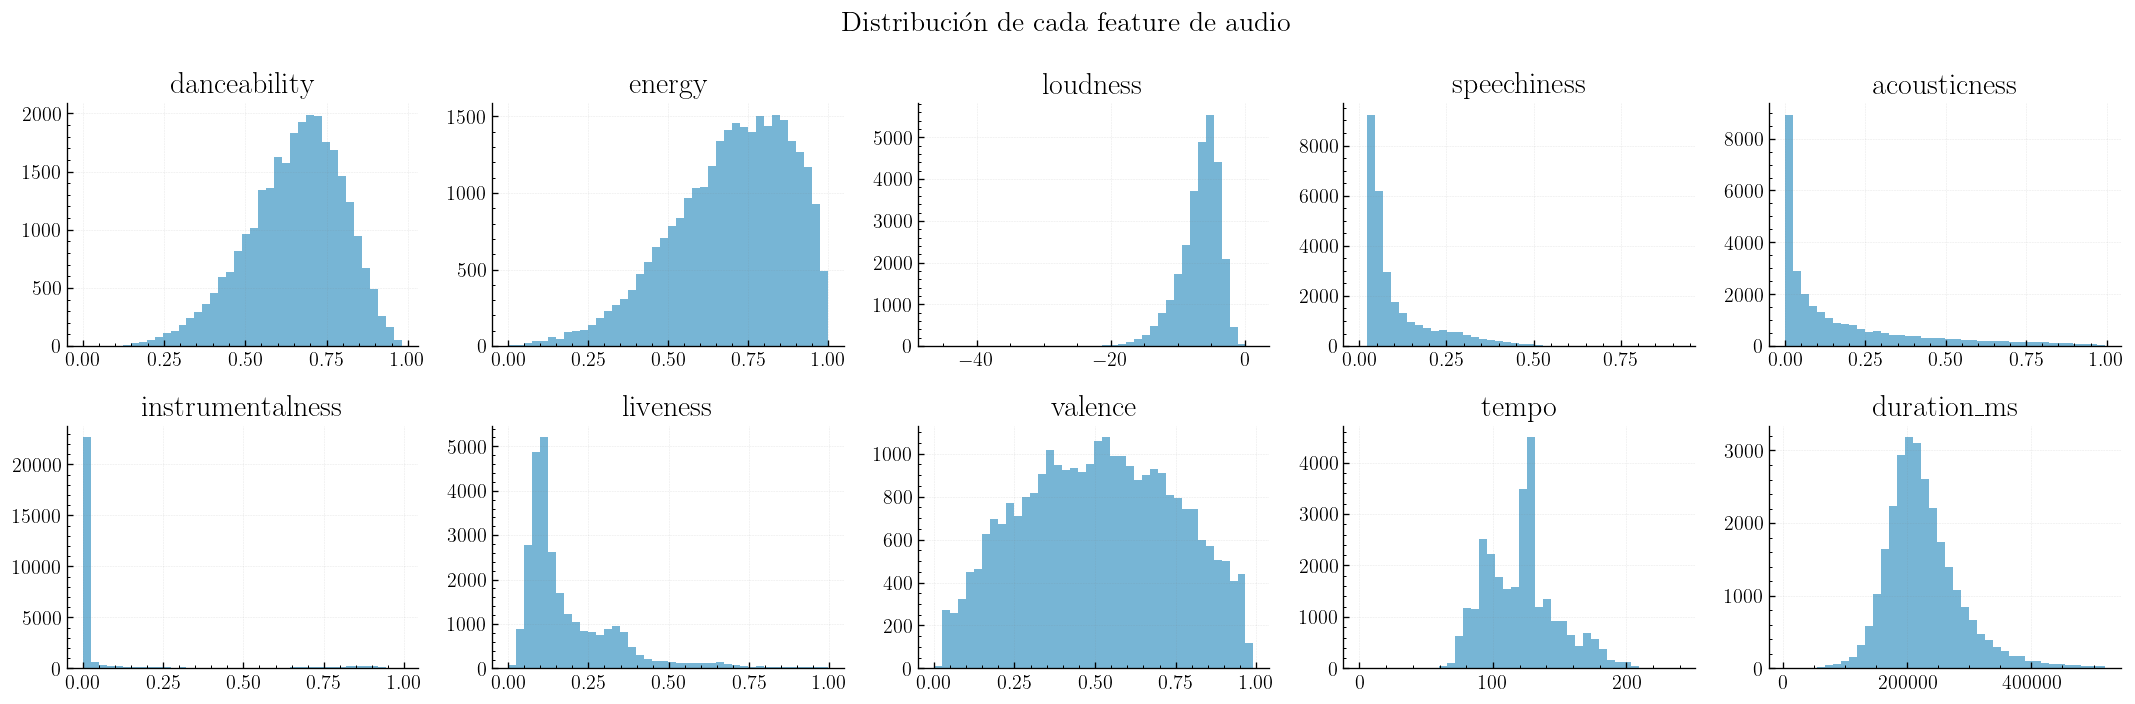

In [13]:
# ── Exploración visual: ¿qué contienen las features? ──────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for ax, feat in zip(axes, AUDIO_FEATURES):
    ax.hist(df[feat], bins=40, color='#4A9CC7', alpha=0.75, edgecolor='none')
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.2)

plt.suptitle('Distribución de cada feature de audio')
plt.tight_layout()
plt.show()

---
## Mínimos cuadrados en 2D

### `loudness` → `energy`

`loudness` mide el volumen promedio en dB (valores negativos, típicamente entre -60 y 0).
`energy` mide la intensidad perceptual, entre 0 y 1.

La relación entre ambas debería ser aproximadamente lineal — canciones más fuertes tienden a sentirse más energéticas.

**Modelo**: $\text{energy}_k = c_0 + c_1 \cdot \text{loudness}_k + \varepsilon_k$

En forma matricial: $A\mathbf{c} = \mathbf{y}$ con
$$A = \begin{pmatrix}1 & \text{loudness}_1 \\ \vdots & \vdots \\ 1 & \text{loudness}_N\end{pmatrix} \in \mathbb{R}^{N \times 2}, \qquad \mathbf{c} = \begin{pmatrix}c_0 \\ c_1\end{pmatrix}, \qquad \mathbf{y} = \begin{pmatrix}\text{energy}_1 \\ \vdots \\ \text{energy}_N\end{pmatrix}$$

In [14]:
# Datos
x = df['loudness'].values      # loudness: variable independiente
y = df['energy'].values        # energy: variable dependiente
N = len(x)

# ── EJERCICIO 1 ───────────────────────────────────────────────────────────
# Construye la matriz A de colocación.
# Primera columna: unos (término independiente c_0)
# Segunda columna: valores de loudness (coeficiente c_1)
#
# A debe tener shape (N, 2)
# Pista: np.ones(N), np.column_stack

A = np.column_stack([np.ones(N), x])


In [15]:
# ── EJERCICIO 2 ───────────────────────────────────────────────────────────
# Resuelve las ecuaciones normales A^T A c = A^T y
# SIN usar np.linalg.lstsq — hazlo paso a paso:
#   1. Calcula AtA = A.T @ A
#   2. Calcula Aty = A.T @ y
#   3. Resuelve AtA @ c = Aty con np.linalg.solve

AtA = A.T @ A
Aty = A.T @ y
c_normal = np.linalg.solve(AtA, Aty)

# Verificación: compara con lstsq
c_lstsq, _, _, _ = np.linalg.lstsq(A, y, rcond=None)

assert c_normal is not None, 'Resuelve el sistema'
print(f'Ecuaciones normales: c = {c_normal}')
print(f'lstsq (referencia):  c = {c_lstsq}')
print(f'Diferencia: {np.abs(c_normal - c_lstsq).max():.2e}  (debe ser ~0)')
print(f'\nInterpretación:')
print(f'  c_0 = {c_normal[0]:.4f}  (energy cuando loudness = 0 dB)')
print(f'  c_1 = {c_normal[1]:.4f}  (cambio en energy por cada dB de loudness)')


LinAlgError: 0-dimensional array given. Array must be two-dimensional

In [ ]:
# ── Visualización: la proyección ortogonal ────────────────────────────────
x_line = np.linspace(x.min(), x.max(), 200)
y_line = c_lstsq[0] + c_lstsq[1] * x_line

# Residuos
y_pred = A @ c_lstsq
residuos = y - y_pred
rms = np.sqrt(np.mean(residuos**2))

# Colorear por género
genres = df['playlist_genre'].values
genre_list = sorted(df['playlist_genre'].unique())
colors_g = plt.cm.tab10(np.linspace(0, 0.6, len(genre_list)))
genre_color = {g: c for g, c in zip(genre_list, colors_g)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: datos + recta
ax = axes[0]
for g in genre_list:
    mask = genres == g
    ax.scatter(x[mask], y[mask], s=4, alpha=0.3,
               color=genre_color[g], label=g)
ax.plot(x_line, y_line, '-', color='#C0392B', lw=2.5,
        label=f'LS: energy = {c_lstsq[0]:.3f} + {c_lstsq[1]:.4f}·loudness')
ax.set_xlabel('loudness (dB)', fontsize=11)
ax.set_ylabel('energy', fontsize=11)
ax.set_title('LS en 2D: loudness → energy', fontsize=12)
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.2)

# Panel derecho: distribución de residuos
ax2 = axes[1]
ax2.hist(residuos, bins=60, color='#4A9CC7', alpha=0.8, edgecolor='none')
ax2.axvline(0, color='#C0392B', lw=2, label='media = 0')
ax2.axvline(residuos.mean(), color='#D4A843', lw=2, ls='--',
            label=f'media = {residuos.mean():.4f}')
ax2.set_xlabel('residuo = energy - ŷ', fontsize=11)
ax2.set_ylabel('frecuencia', fontsize=11)
ax2.set_title(f'Distribución de residuos\nRMS = {rms:.4f}', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


### Preguntas importantes

1. **Residuos**: ¿la media de los residuos es exactamente 0?. ¿Por qué? 

2. **Número de condición**: ejecuta `np.linalg.cond(A)` y `np.linalg.cond(A.T @ A)`. ¿Qué relación tienen? ¿El sistema está bien condicionado?

3. **Bases alternativas**: en lugar de $\phi_0=1$, $\phi_1=\text{loudness}$, prueba agregar $\phi_2=\text{loudness}^2$. ¿Mejora el RMS? ¿Qué pasa con el número de condición?
```python
A3 = np.column_stack([np.ones(N), x, x**2])
c3, _, _, _ = np.linalg.lstsq(A3, y, rcond=None)
```

4. **Proyección**: `y_pred = A @ c_lstsq` es la proyección de `y` sobre `col(A)`. Verifica que el residuo es perpendicular a cada columna de $A$.

---
## Bloque 3: PCA — la base que emerge de los datos

Ahora no hay variable de salida. Tenemos las 10 features de audio y queremos entender su estructura.

**Problema**: $\min_{W^TW=I_k,\, Z} \|\tilde{X} - ZW^T\|_F^2$

donde:
- $\tilde{X} \in \mathbb{R}^{N \times 10}$: features centradas (ya normalizadas, media 0)
- $W \in \mathbb{R}^{10 \times k}$: la base óptima (componentes principales)
- $Z \in \mathbb{R}^{N \times k}$: coordenadas de cada canción en la nueva base

La solución es $W^* = V_k$ (columnas derechas de la SVD de $\tilde{X}$).

In [ ]:
# ── Datos centrados ───────────────────────────────────────────────────────

# Normalizar features (media 0, std 1) para comparar coeficientes
X_raw = df[AUDIO_FEATURES].values  # shape (N, 10)
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X_norm = (X_raw - X_mean) / X_std  # shape (N, 10), cada columna tiene media 0 std 1

# X_norm ya tiene media 0 por columna
X_tilde = X_norm.copy()  # shape (N, 10)
print(f'X_tilde shape: {X_tilde.shape}')
print(f'Media por columna (debe ser ~0): {X_tilde.mean(axis=0).round(4)}')

# ── EJERCICIO 4 ───────────────────────────────────────────────────────────
# Calcula la SVD de X_tilde
# Usa np.linalg.svd con full_matrices=False
# Debes obtener:
#   U:  shape (N, 10)  — vectores singulares izquierdos
#   s:  shape (10,)    — valores singulares (no la matriz Sigma, solo el vector diagonal)
#   Vt: shape (10, 10) — vectores singulares derechos transpuestos

U, s, Vt = np.linalg.svd(X_tilde, full_matrices=False)


X_tilde shape: (28356, 10)
Media por columna (debe ser ~0): [ 0. -0.  0.  0.  0.  0. -0.  0.  0. -0.]


AttributeError: 'NoneType' object has no attribute 'T'

In [ ]:
# ── Varianza explicada ────────────────────────────────────────────────────
var_exp = s**2 / s**2.sum()   # fracción de varianza por componente
var_acum = np.cumsum(var_exp)  # varianza acumulada

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, 11), var_exp * 100, color='#4A9CC7', alpha=0.85, edgecolor='none')
ax.set_xlabel('Componente principal', fontsize=10)
ax.set_ylabel('Varianza explicada (%)', fontsize=10)
ax.set_title('Varianza por componente\n$\\sigma_j^2 / \\sum_i \\sigma_i^2$', fontsize=11)
ax.grid(True, alpha=0.2, axis='y')
for i, v in enumerate(var_exp):
    ax.text(i+1, v*100+0.5, f'{v*100:.1f}%', ha='center', fontsize=8)

ax2 = axes[1]
ax2.plot(range(1, 11), var_acum * 100, 'o-', color='#C0392B', lw=2, ms=7)
ax2.axhline(90, color='gray', ls='--', lw=1, label='90%')
ax2.axhline(95, color='gray', ls=':', lw=1, label='95%')
k90 = np.searchsorted(var_acum, 0.90) + 1
k95 = np.searchsorted(var_acum, 0.95) + 1
ax2.axvline(k90, color='#D4A843', ls='--', lw=1.5, label=f'k={k90} para 90%')
ax2.axvline(k95, color='#2AB0A0', ls='--', lw=1.5, label=f'k={k95} para 95%')
ax2.set_xlabel('k (número de componentes)', fontsize=10)
ax2.set_ylabel('Varianza acumulada (%)', fontsize=10)
ax2.set_title('Varianza acumulada', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Con k=2 componentes: {var_acum[1]*100:.1f}% de la varianza')
print(f'Con k=3 componentes: {var_acum[2]*100:.1f}% de la varianza')
print(f'Para 90% de varianza: k = {k90}')
print(f'Para 95% de varianza: k = {k95}')


In [ ]:
# ── EJERCICIO ───────────────────────────────────────────────────────────
# Calcula las coordenadas Z de las canciones en los primeros k=2 componentes
# Z = X_tilde @ V_k  donde V_k son las primeras 2 columnas de V
# Z debe tener shape (N, 2)

k = 2
V_k = Vt.T[:, :k]  # Vt = V^T, entonces V = Vt.T
Z   = X_tilde @ V_k

assert Z is not None, 'Calcula Z'
assert Z.shape == (len(X_tilde), k), f'Z debe ser ({len(X_tilde)}, {k})'

# Verificar que Z = U_k @ Sigma_k
Z_svd = U[:, :k] * s[:k]  # equivalente
print(f'Z shape: {Z.shape}')
print(f'Z = X_tilde @ V_k  vs  U_k Sigma_k: max diff = {np.abs(Z - Z_svd).max():.2e}')
print('  (deben ser iguales salvo signo)')

In [ ]:
 ## ── Visualización: nube en 2D coloreada por género ────────────────────────

genres_arr = df['playlist_genre'].values
genre_list = sorted(df['playlist_genre'].unique())
palette = ['#C0392B', '#2AB0A0', '#D4A843', '#7B68EE', '#4A9CC7']
gcolor = {g: c for g, c in zip(genre_list, palette)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: PC1 vs PC2 coloreado por género
ax = axes[0]
for g in genre_list:
    mask = genres_arr == g
    ax.scatter(Z[mask, 0], Z[mask, 1], s=5, alpha=0.35,
               color=gcolor[g], label=g)
ax.set_xlabel(f'PC$_1$ ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC$_2$ ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Canciones de Spotify en espacio PCA\n'
             '¿Se separan los géneros?', fontsize=12)
ax.legend(fontsize=9, markerscale=4)
ax.grid(True, alpha=0.2)

# Panel derecho: biplot — componentes principales como vectores
ax2 = axes[1]
# Nube de puntos (subsample para claridad)
idx_sub = np.random.choice(len(Z), 1000, replace=False)
for g in genre_list:
    mask = genres_arr[idx_sub] == g
    ax2.scatter(Z[idx_sub][mask, 0], Z[idx_sub][mask, 1],
                s=5, alpha=0.3, color=gcolor[g])

# Vectores de carga (loadings): V_k escalado por valores singulares
scale = s[:2] * 0.3
for i, feat in enumerate(AUDIO_FEATURES):
    ax2.annotate('', xy=(V_k[i,0]*scale[0], V_k[i,1]*scale[1]), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))
    ax2.text(V_k[i,0]*scale[0]*1.12, V_k[i,1]*scale[1]*1.12,
             feat, fontsize=8, color='#C0392B', ha='center')

ax2.set_xlabel(f'PC$_1$', fontsize=11)
ax2.set_ylabel(f'PC$_2$', fontsize=11)
ax2.set_title('Biplot: canciones + direcciones de features', fontsize=12)
ax2.axhline(0, color='gray', lw=0.5); ax2.axvline(0, color='gray', lw=0.5)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
